<h4><b>Regressão linear simples</b></h4>
<p>Experimento com amostra de dados grande visando obter análises iniciais.</p>
<ul>
    <li>Feature previsora: distance</li>    
    <li>Feature target: duration</li>
    <li>Cross-validation</li>
</ul>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.regressor import ResidualsPlot

In [4]:
!python --version

Python 3.10.13


In [6]:
path = '/media/marcos/500GB/00_datasets/big/big_travel_duration_df.csv'
df = pd.read_csv(path)

In [7]:
X = df.iloc[:,0].values
X = X.reshape(-1,1)

In [8]:
y = df.iloc[:,1].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [10]:
simple_regressor = LinearRegression()

In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

In [12]:
mae_scores_train = -cross_val_score(simple_regressor, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
mae_scores_test = -cross_val_score(simple_regressor, X_test, y_test, cv=cv, scoring='neg_mean_absolute_error')

In [13]:
simple_regressor.fit(X_train, y_train)

LinearRegression()

In [14]:
y_train_pred = simple_regressor.predict(X_train)
y_test_pred = simple_regressor.predict(X_test)

In [15]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

In [16]:
mae_test_std = np.std(np.abs(y_test_pred - y_test))

mse_train_std = np.std((y_train_pred - y_train) ** 2)
mse_test_std = np.std((y_test_pred - y_test) ** 2)

rmse_train_std = np.std(np.sqrt((y_train_pred - y_train) ** 2))
rmse_test_std = np.std(np.sqrt((y_test_pred - y_test) ** 2))

In [17]:
print("MAE para cada fold na Cross-Validation (dados de treino):")
for i, score in enumerate(mae_scores_train, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nMAE para cada fold na Cross-Validation (dados de teste):")
for i, score in enumerate(mae_scores_test, 1):
    print(f"Fold {i}: {score:.4f}")

print("-" * 60)
print(f"MAE treino: {mae_scores_train.mean():.4f} \u00b1 {mae_scores_train.std():.4f}")
print(f"MAE teste: {mae_test:.4f} \u00b1 {mae_test_std:.4f}")

print(f"MSE treino: {mse_train:.4f} \u00b1 {mse_train_std:.4f}")
print(f"MSE teste: {mse_test:.4f} \u00b1 {mse_test_std:.4f}")

print(f"RMSE treino: {rmse_train:.4f} \u00b1 {rmse_train_std:.4f}")
print(f"RMSE teste: {rmse_test:.4f} \u00b1 {rmse_test_std:.4f}")

print(f"R² treino: {r2_train:.4f}")
print(f"R² teste: {r2_test:.4f}")

MAE para cada fold na Cross-Validation (dados de treino):
Fold 1: 224.2845
Fold 2: 221.1869
Fold 3: 227.2962
Fold 4: 223.5042
Fold 5: 229.8269

MAE para cada fold na Cross-Validation (dados de teste):
Fold 1: 217.8948
Fold 2: 221.6355
Fold 3: 214.4085
Fold 4: 215.8374
Fold 5: 238.0413
------------------------------------------------------------
MAE treino: 225.2198 ± 3.0206
MAE teste: 221.8199 ± 157.3151
MSE treino: 76540.3458 ± 101132.8019
MSE teste: 73952.1349 ± 95877.2914
RMSE treino: 276.6593 ± 160.8526
RMSE teste: 271.9414 ± 157.3151
R² treino: 0.7425
R² teste: 0.7445


In [18]:
train_sizes, train_scores, test_scores = learning_curve(
    simple_regressor,                  # Modelo SVR
    X_train,                     # Dados de entrada
    y_train.ravel(),             # Rótulos (vetor)
    cv=5,                               # Número de folds na validação cruzada
    scoring='neg_mean_absolute_error',   # Métrica de avaliação
    n_jobs=-1,                          # Paralelização
    train_sizes=np.linspace(0.1, 1.0, 10)  # Frações do conjunto de treinamento
)

In [19]:
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

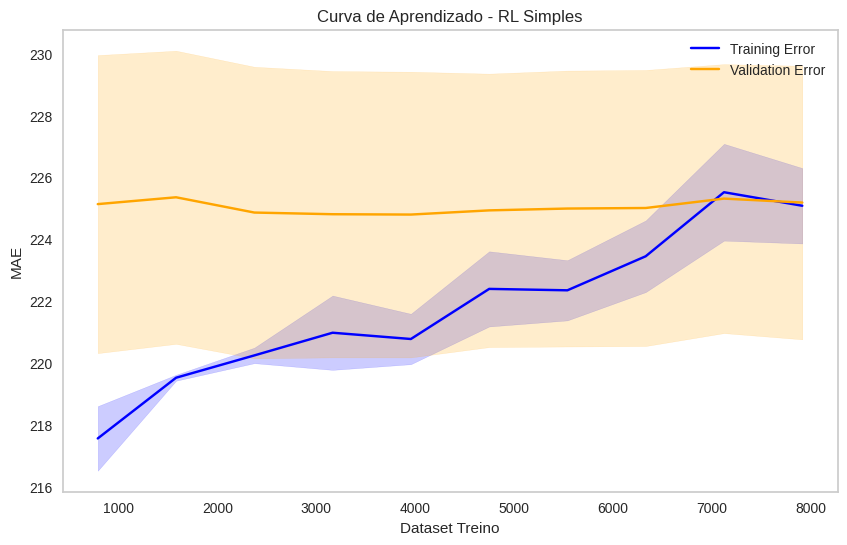

In [22]:
plt.figure(figsize=(10, 6))

# Plotar a média do erro no conjunto de treino
plt.plot(train_sizes, train_mean, label="Training Error", color="blue")

# Adicionar faixa de desvio padrão
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)

# Plotar a média do erro no conjunto de validação
plt.plot(train_sizes, test_mean, label="Validation Error", color="orange")

# Adicionar faixa de desvio padrão
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="orange", alpha=0.2)

# Detalhes do gráfico
plt.title("Curva de Aprendizado - RL Simples")
plt.xlabel("Dataset Treino")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid()
plt.savefig('rl_simples_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()